# 03 - Inspection Image Preprocessing Pipeline

**Purpose:** Show how raw product images are cleaned and normalized before defect detection.

**Expected output:** Real MVTec bottle image through resize, grayscale, denoise, contrast, brightness, shadow reduction, thresholding, edge detection, and before/after summary.

**Platform connection:** These transformations explain why the anomaly detector receives stable model-ready input instead of raw noisy images.


In [1]:
from pathlib import Path
import json
import sys

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

BOTTLE_DIR = PROJECT_ROOT / "data" / "raw" / "mvtec_anomaly_detection" / "bottle"
IMAGE_SIZE = (256, 256)
LABELS = ["good", "broken_large", "broken_small", "contamination"]


def read_rgb(path):
    image_bgr = cv2.imread(str(path))
    if image_bgr is None:
        raise FileNotFoundError(f"Could not read image: {path}")
    return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)


def first_image(label="contamination", split="test"):
    folder = BOTTLE_DIR / split / label
    images = sorted(folder.glob("*.png"))
    if not images:
        raise FileNotFoundError(f"No images found in {folder}")
    return images[0]


def show_grid(items, cols=4, figsize=(14, 7), suptitle=None):
    rows = int(np.ceil(len(items) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = np.atleast_1d(axes).ravel()
    for ax, item in zip(axes, items):
        title, image, cmap = item
        ax.imshow(image, cmap=cmap)
        ax.set_title(title, fontsize=11, fontweight="bold")
        ax.axis("off")
    for ax in axes[len(items):]:
        ax.axis("off")
    if suptitle:
        fig.suptitle(suptitle, fontsize=15, fontweight="bold")
    plt.tight_layout()
    plt.show()


print("Project root:", PROJECT_ROOT)
print("MVTec bottle folder exists:", BOTTLE_DIR.exists())


Project root: C:\Users\HP\Desktop\springboard\visioninspect-ai-github
MVTec bottle folder exists: True


## Select Real Bottle Images


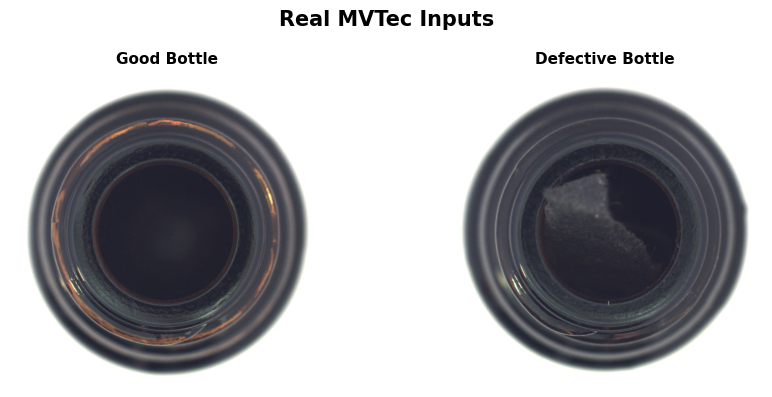

,role,path,shape
0,good reference,C:\Users\HP\Desktop\springboard\visioninspect-...,"(900, 900, 3)"
1,defective sample,C:\Users\HP\Desktop\springboard\visioninspect-...,"(900, 900, 3)"


In [2]:
defective_path = first_image("contamination", "test")
good_path = first_image("good", "test")
defective_rgb = read_rgb(defective_path)
good_rgb = read_rgb(good_path)
show_grid([("Good Bottle", good_rgb, None), ("Defective Bottle", defective_rgb, None)], cols=2, figsize=(9, 4), suptitle="Real MVTec Inputs")
display(pd.DataFrame([
    {"role": "good reference", "path": str(good_path), "shape": str(good_rgb.shape)},
    {"role": "defective sample", "path": str(defective_path), "shape": str(defective_rgb.shape)},
]))


## Preprocessing Pipeline Stages


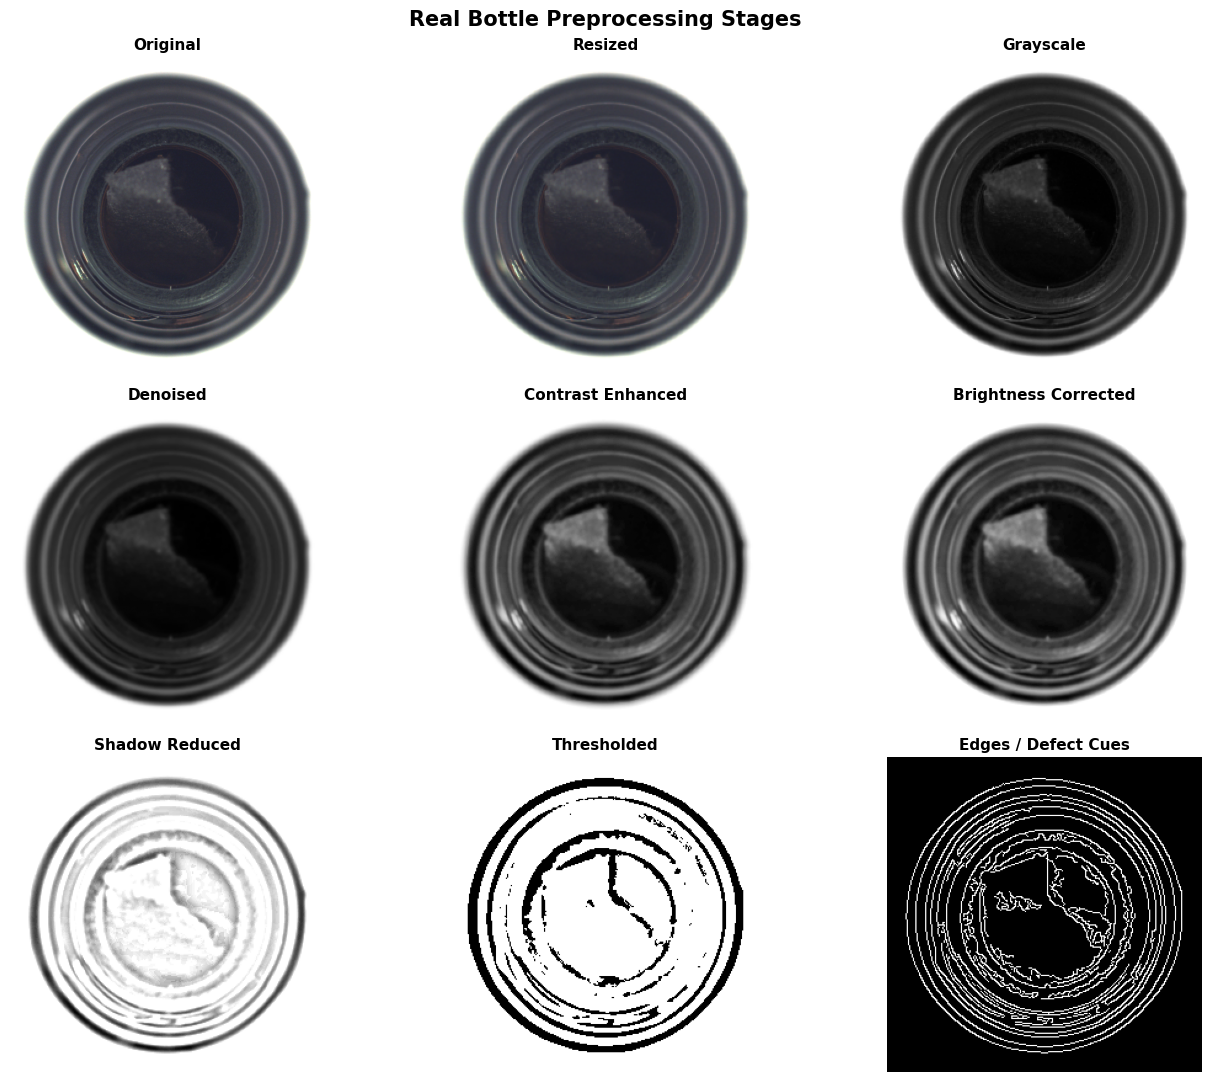

In [3]:
resized = cv2.resize(defective_rgb, IMAGE_SIZE, interpolation=cv2.INTER_AREA)
gray = cv2.cvtColor(resized, cv2.COLOR_RGB2GRAY)
denoised = cv2.GaussianBlur(gray, (5, 5), 0)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
contrast = clahe.apply(denoised)
brightness = cv2.convertScaleAbs(contrast, alpha=1.08, beta=8)
background = cv2.GaussianBlur(brightness, (31, 31), 0)
shadow_reduced = cv2.divide(brightness, background, scale=255)
_, thresholded = cv2.threshold(shadow_reduced, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
edges = cv2.Canny(shadow_reduced, 50, 150)
show_grid([
    ("Original", defective_rgb, None), ("Resized", resized, None), ("Grayscale", gray, "gray"),
    ("Denoised", denoised, "gray"), ("Contrast Enhanced", contrast, "gray"), ("Brightness Corrected", brightness, "gray"),
    ("Shadow Reduced", shadow_reduced, "gray"), ("Thresholded", thresholded, "gray"), ("Edges / Defect Cues", edges, "gray"),
], cols=3, figsize=(14, 11), suptitle="Real Bottle Preprocessing Stages")


## Preprocessing Impact Table


In [4]:
display(pd.DataFrame([
    {"stage": "resize", "problem_addressed": "different image sizes", "model_benefit": "consistent input shape"},
    {"stage": "grayscale", "problem_addressed": "color not always required", "model_benefit": "simpler intensity analysis"},
    {"stage": "denoising", "problem_addressed": "sensor/image noise", "model_benefit": "cleaner anomaly map"},
    {"stage": "contrast enhancement", "problem_addressed": "low contrast defects", "model_benefit": "defects become more separable"},
    {"stage": "shadow reduction", "problem_addressed": "uneven lighting", "model_benefit": "fewer lighting false alarms"},
    {"stage": "threshold/edges", "problem_addressed": "local structural changes", "model_benefit": "visual defect cues"},
]))


,stage,problem_addressed,model_benefit
0,resize,different image sizes,consistent input shape
1,grayscale,color not always required,simpler intensity analysis
2,denoising,sensor/image noise,cleaner anomaly map
3,contrast enhancement,low contrast defects,defects become more separable
4,shadow reduction,uneven lighting,fewer lighting false alarms
5,threshold/edges,local structural changes,visual defect cues


## Good vs Defective Edge Cues


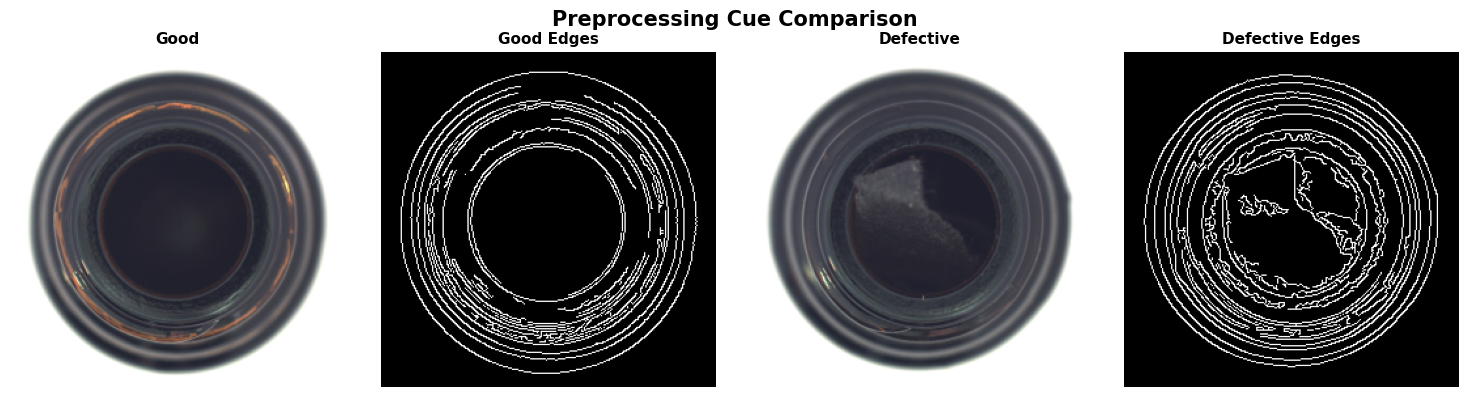

,image,edge_pixels_percent
0,good,9.47
1,defective,11.65


In [5]:
good_resized = cv2.resize(good_rgb, IMAGE_SIZE, interpolation=cv2.INTER_AREA)
good_gray = cv2.cvtColor(good_resized, cv2.COLOR_RGB2GRAY)
good_edges = cv2.Canny(good_gray, 50, 150)
show_grid([
    ("Good", good_resized, None), ("Good Edges", good_edges, "gray"),
    ("Defective", resized, None), ("Defective Edges", edges, "gray"),
], cols=4, figsize=(15, 4), suptitle="Preprocessing Cue Comparison")
display(pd.DataFrame([
    {"image": "good", "edge_pixels_percent": round(float(np.mean(good_edges > 0) * 100), 2)},
    {"image": "defective", "edge_pixels_percent": round(float(np.mean(edges > 0) * 100), 2)},
]))


## Before vs After Preprocessing Summary

This compact comparison shows the practical improvement produced by preprocessing before anomaly detection.


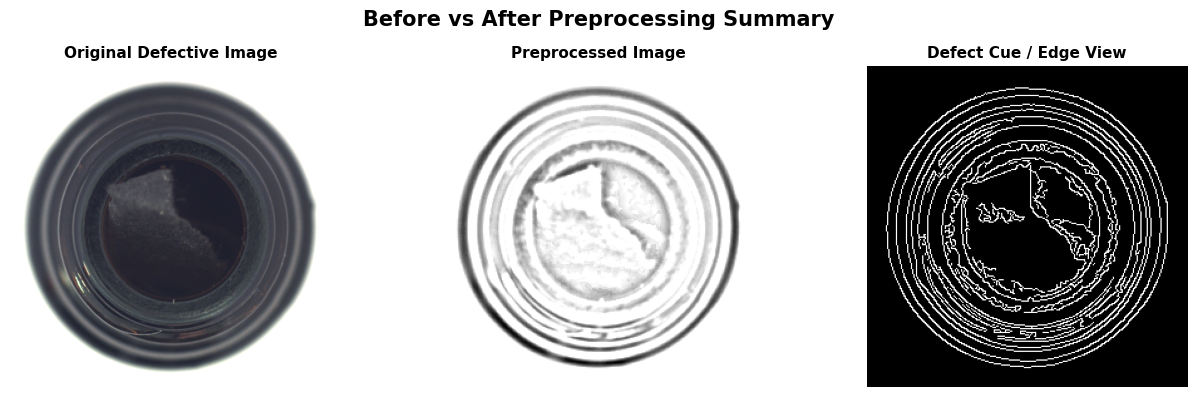

,stage,role,risk
0,Original,raw camera/upload input,"lighting, noise, and contrast can hide defects"
1,Preprocessed,normalized model input,reduced noise and stronger contrast
2,Defect cue view,visual signal for anomaly detection,surface edges and abnormal regions become easi...


In [6]:
preprocessed_view = shadow_reduced
cue_view = edges

show_grid([
    ("Original Defective Image", defective_rgb, None),
    ("Preprocessed Image", preprocessed_view, "gray"),
    ("Defect Cue / Edge View", cue_view, "gray"),
], cols=3, figsize=(13, 4), suptitle="Before vs After Preprocessing Summary")

before_after_df = pd.DataFrame([
    {"stage": "Original", "role": "raw camera/upload input", "risk": "lighting, noise, and contrast can hide defects"},
    {"stage": "Preprocessed", "role": "normalized model input", "risk": "reduced noise and stronger contrast"},
    {"stage": "Defect cue view", "role": "visual signal for anomaly detection", "risk": "surface edges and abnormal regions become easier to inspect"},
])
display(before_after_df)


## Preprocessing Quality Metrics

These numeric checks make preprocessing measurable instead of only visual.


,stage,mean,std_contrast,sharpness_laplacian_var
0,grayscale,136.01,92.29,167.47
1,denoised,136.01,91.73,19.00
2,contrast_enhanced,144.46,87.86,69.38
3,shadow_reduced,237.19,33.27,356.62


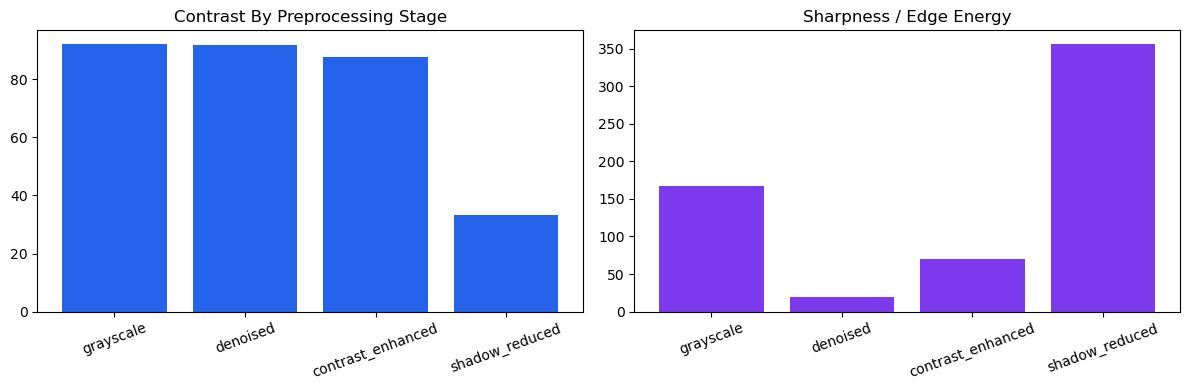

In [7]:
def laplacian_variance(img_gray):
    return float(cv2.Laplacian(img_gray, cv2.CV_64F).var())

quality_df = pd.DataFrame([
    {"stage": "grayscale", "mean": round(float(gray.mean()), 2), "std_contrast": round(float(gray.std()), 2), "sharpness_laplacian_var": round(laplacian_variance(gray), 2)},
    {"stage": "denoised", "mean": round(float(denoised.mean()), 2), "std_contrast": round(float(denoised.std()), 2), "sharpness_laplacian_var": round(laplacian_variance(denoised), 2)},
    {"stage": "contrast_enhanced", "mean": round(float(contrast.mean()), 2), "std_contrast": round(float(contrast.std()), 2), "sharpness_laplacian_var": round(laplacian_variance(contrast), 2)},
    {"stage": "shadow_reduced", "mean": round(float(shadow_reduced.mean()), 2), "std_contrast": round(float(shadow_reduced.std()), 2), "sharpness_laplacian_var": round(laplacian_variance(shadow_reduced), 2)},
])
display(quality_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(quality_df["stage"], quality_df["std_contrast"], color="#2563eb")
axes[0].set_title("Contrast By Preprocessing Stage")
axes[0].tick_params(axis="x", rotation=20)
axes[1].bar(quality_df["stage"], quality_df["sharpness_laplacian_var"], color="#7c3aed")
axes[1].set_title("Sharpness / Edge Energy")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()


## Validation Outcome

- The preprocessing module handles real inspection images.
- Cleaning and contrast steps make defect cues easier to inspect.
- These stages explain how anomaly detectors receive normalized visual input.
